In [1]:
# Fraud Detection Analysis in Banking Transactions

# This project analyzes banking transaction data to identify patterns associated with fraudulent activity.

# The goal is to explore transaction behavior and identify indicators that may signal fraudulent transactions.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:/Users/kwinanzu/Fraud_Detection_Analysis/Dataset/FraudShield_Banking_Data.csv")

In [4]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

In [6]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count
count,49997.000000,49990.000000,49991.000000,49993.000000,49998.000000,49991.000000,49991.000000,49991.000000,49995.000000,49991.000000,49996.000000,49989.000000,49997.000000
mean,550400.968898,54869.720744,4.999880,54951.375913,300.098564,552563.600088,20.993179,3.999460,12.520032,2.989098,5.016781,0.992798,0.500130
std,259677.602349,26052.824933,2.582025,25983.342481,172.848263,260186.451027,10.685467,2.002833,6.910709,1.413400,2.572913,0.816081,0.500005
min,100043.000000,10005.000000,1.000000,10001.000000,1.000000,100053.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,324445.000000,32259.250000,3.000000,32545.000000,150.000000,327643.500000,12.000000,2.000000,7.000000,2.000000,3.000000,0.000000,0.000000
50%,552115.000000,54720.500000,5.000000,54935.000000,301.000000,553372.000000,21.000000,4.000000,13.000000,3.000000,5.000000,1.000000,1.000000
75%,775942.000000,77542.000000,7.000000,77341.000000,449.000000,779903.500000,30.000000,6.000000,18.000000,4.000000,7.000000,2.000000,1.000000
max,999992.000000,99996.000000,9.000000,99996.000000,599.000000,999989.000000,39.000000,7.000000,24.000000,5.000000,9.000000,2.000000,1.000000


In [7]:
df.isnull().sum()

Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Time                          9
Transaction_Date                          3
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction        

In [8]:
df['Fraud_Label'].value_counts()

Fraud_Label
Normal    47573
Fraud      2423
Name: count, dtype: int64

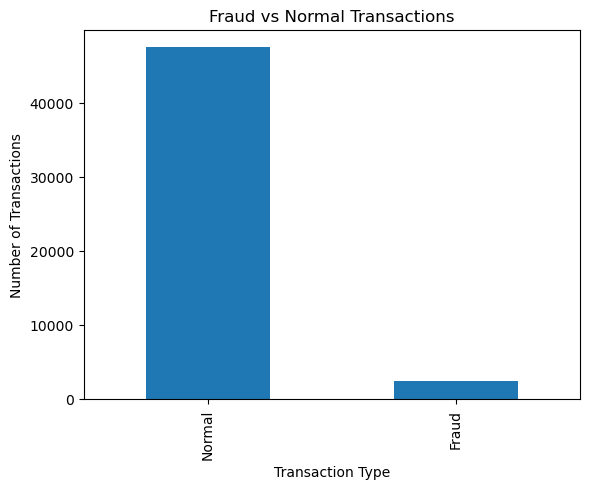

In [9]:
# Adding a chart

fraud_counts = df['Fraud_Label'].value_counts()

plt.figure()
fraud_counts.plot(kind = 'bar')

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.savefig("fraud_distribution.png")
plt.show()

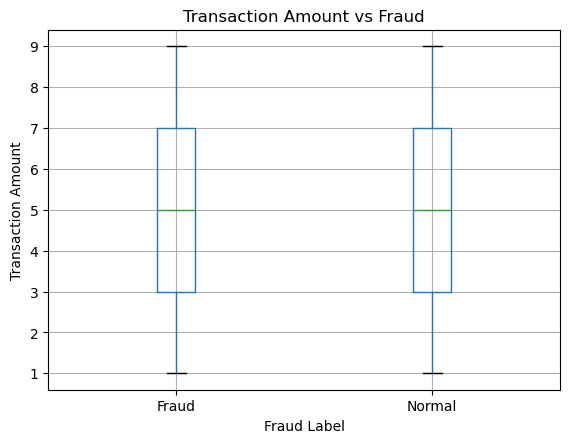

In [10]:
# Check the average transactions amount for fraud vs normal

df.boxplot(column='Transaction_Amount (in Million)', by='Fraud_Label')

plt.title("Transaction Amount vs Fraud")
plt.suptitle("")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount")

plt.savefig("transaction amount vs fraud.png")
plt.show()

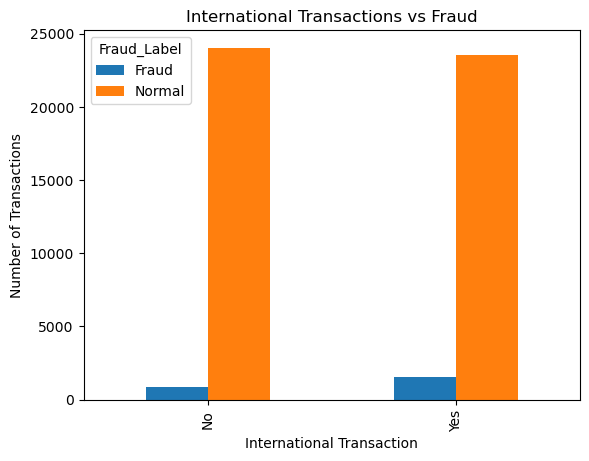

In [11]:
# Check if fraud occurs more in international transactions

pd.crosstab(df['Is_International_Transaction'], df['Fraud_Label']).plot(kind='bar')

plt.title("International Transactions vs Fraud")
plt.xlabel("International Transaction")
plt.ylabel("Number of Transactions")

plt.savefig("international transactions vs fraud.png")
plt.show()

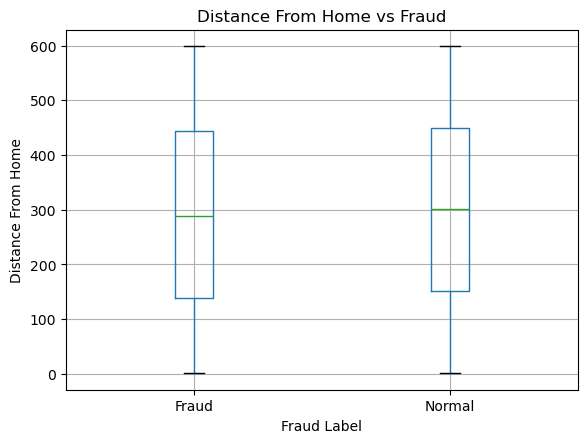

In [12]:
# Find out how far the transaction occured from the customer's home

df.groupby('Fraud_Label')['Distance_From_Home'].mean()
df.boxplot(column = 'Distance_From_Home', by = 'Fraud_Label')

plt.title("Distance From Home vs Fraud")
plt.suptitle("")
plt.xlabel("Fraud Label")
plt.ylabel("Distance From Home")

plt.savefig("distance from home vs fraud.png")
plt.show()

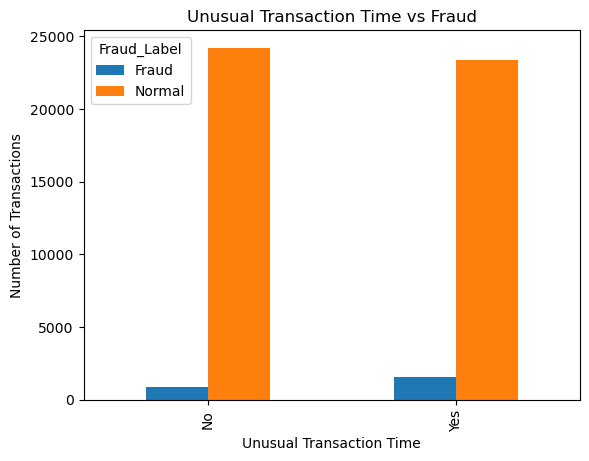

In [13]:
# Check if fraud occurs at unusual times

pd.crosstab(df['Unusual_Time_Transaction'], df['Fraud_Label']).plot(kind='bar')

plt.title("Unusual Transaction Time vs Fraud")
plt.xlabel("Unusual Transaction Time")
plt.ylabel("Number of Transactions")

plt.savefig("unusual transaction times.png")
plt.show()


In [14]:
# Previous fraud history

df.groupby('Fraud_Label')['Previous_Fraud_Count'].mean()

Fraud_Label
Fraud     0.510937
Normal    0.499580
Name: Previous_Fraud_Count, dtype: float64

In [15]:
'''
This analysis identified several behavioral patterns associated with fraudlent banking transactions.
Key indicators include high transaction amounts, international transactions, unusual tranaction times, and large distance from the customer's home location.
These findings can help financial institutions improve fraud detection systems by incorporating behavioral risk indicators.
'''

"\nThis analysis identified several behavioral patterns associated with fraudlent banking transactions.\nKey indicators include high transaction amounts, international transactions, unusual tranaction times, and large distance from the customer's home location.\nThese findings can help financial institutions improve fraud detection systems by incorporating behavioral risk indicators.\n"